#Problem Statement 1

##Problem Objective

The goal is to understand how foot injuries are distributed across different playing positions and calculate key probabilities that help interpret injury risk.

##Creating the Dataset

In [7]:
import pandas as pd
data = {
    "Striker": [45,32],
    "Forward": [56,38],
    "Attacking Midfielder": [24,11],
    "Winger": [20,9]
}

index = ["Injured", "Not Injured"]

df = pd.DataFrame(data, index=index)
print(df)

             Striker  Forward  Attacking Midfielder  Winger
Injured           45       56                    24      20
Not Injured       32       38                    11       9


###Observation:-

The table shows the number of injured and non-injured players for each position.

##Adding totals

In [8]:
df["Total"] = df.sum(axis=1)
df.loc["Total"] = df.sum()
print(df)

             Striker  Forward  Attacking Midfielder  Winger  Total
Injured           45       56                    24      20    145
Not Injured       32       38                    11       9     90
Total             77       94                    35      29    235


###Observation:-

There are 235 players in total, out of which 145 are injured and 90 are not injured.

##1.1 What is the probability that a randomly chosen player would suffer an injury?

In [9]:
total_players = df.loc["Total", "Total"]
injured_players = df.loc["Injured", "Total"]

prob_injured = injured_players/total_players
print(prob_injured)

0.6170212765957447


###Observation:-

Approximately 62% of the players have suffered a foot injury, which shows injuries are fairly common in this group.

##1.2 What is the probability that a player is a forward or a winger?

In [10]:
forward_players = df.loc["Total", "Forward"]
winger_players = df.loc["Total", "Winger"]

prob_forward_or_winger = (forward_players + winger_players)/total_players
print(prob_forward_or_winger)

0.5234042553191489


###Observation:-

Just over half of the players (about 52%) play either as forwards or wingers, meaning a large part of the team is in attacking roles.

##1.3 What is the probability that randomly chosen player plays in a striker position and has a foot injury?

In [11]:
injured_strikers = df.loc["Injured", "Striker"]
prob_striker_and_injured = injured_strikers/total_players
print(prob_striker_and_injured)

0.19148936170212766


###Observation:-

Around 19% of all players are injured strikers, which is a noticeable portion of the squad.

##1.4 What is the probability that a randomly chosen injured player is a striker?

In [12]:
prob_striker_given_injured = injured_strikers/injured_players
print(prob_striker_given_injured)

0.3103448275862069


###Observation:-

Among injured players, about 31% are strikers, suggesting this position may need closer monitoring and preventing care.

#Problem Statement 2

##Objective:

The purpose of this analysis is to understand how the breaking strength of gunny bags is distributed and estimate the proportion of bags falling into different strength ranges. This helps the quality team anticipate wastage and material failure risk.

##Defining the Distribution

The breaking strength follows a normal distribution with:


*   Mean (μ) = 5 kg/cm²
*   Standard Deviation (σ) = 1.5 kg/cm²



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mean = 5
std_dev = 1.5

###Observation:-

The average breaking strength is centered at 5, with most values spreading about 1.5 units on either side.

##Visualizing the Distribution

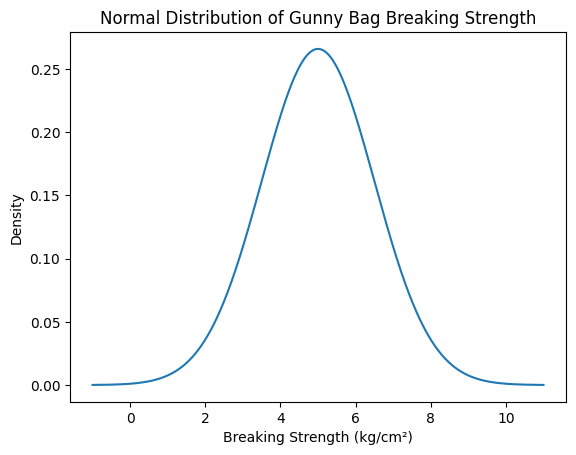

In [14]:
x = np.linspace(mean-4*std_dev, mean+4*std_dev, 1000)
y = norm.pdf(x, mean, std_dev)

plt.figure()
plt.plot(x,y)
plt.title("Normal Distribution of Gunny Bag Breaking Strength")
plt.xlabel("Breaking Strength (kg/cm²)")
plt.ylabel("Density")
plt.show()

###Observation:-

The curve shows a symmetric bell shape centered around 5, which confirms the normal distribution assumption.

##2.1 What proportion of the gunny bags have a breaking strength less than 3.17 kg per sq cm?

0.11123243744783456


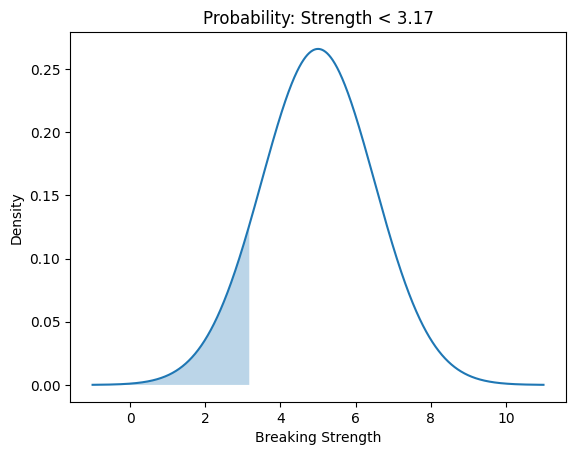

In [15]:
x_value = 3.17
prob_less_3_17 = norm.cdf(x_value, mean, std_dev)
print(prob_less_3_17)

# Visual Representation
x_fill = np.linspace(mean - 4*std_dev, x_value, 500)
y_fill = norm.pdf(x_fill, mean, std_dev)

plt.figure()
plt.plot(x, y)
plt.fill_between(x_fill, y_fill, alpha=0.3)
plt.title("Probability: Strength < 3.17")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

###Observation:-
The shaded area on the left side of the curve represents bags with breaking strength below 3.17. This area is relatively small compared to the full curve, indicating that only a small proportion of bags fall within this low-strength range.

##2.2 What proportion of the gunny bags have a breaking strength of at least 3.6 kg per sq cm.?

0.8246760551477705


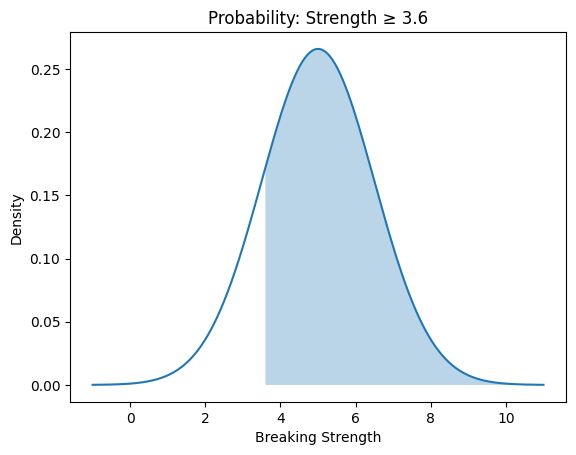

In [16]:
x_value = 3.6
prob_atleast_3_6 = 1- norm.cdf(x_value, mean, std_dev)
print(prob_atleast_3_6)

#Visual Representation
x_fill = np.linspace(x_value, mean + 4*std_dev, 500)
y_fill = norm.pdf(x_fill, mean, std_dev)

plt.figure()
plt.plot(x,y)
plt.fill_between(x_fill, y_fill, alpha=0.3)
plt.title("Probability: Strength ≥ 3.6")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

###Observation:-

A large share of bags meet or exceed 3.6, suggesting acceptable strength consistency.

#2.3 What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?

0.13055865981823633


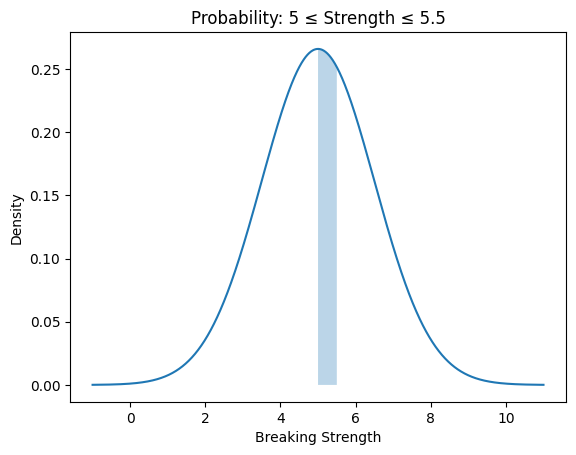

In [17]:
lower = 5
upper = 5.5
prob_between = norm.cdf(upper, mean, std_dev) - norm.cdf(lower, mean, std_dev)
print(prob_between)

#Visual Representation
x_fill = np.linspace(lower, upper, 300)
y_fill = norm.pdf(x_fill, mean, std_dev)

plt.figure()
plt.plot(x,y)
plt.fill_between(x_fill, y_fill, alpha = 0.3)
plt.title("Probability: 5 ≤ Strength ≤ 5.5")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

###Observation:-

Only a moderate portion of bags lie close to the mean range, which is expected in a continuous distribution.

#2.4 What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?

0.13900157199868257


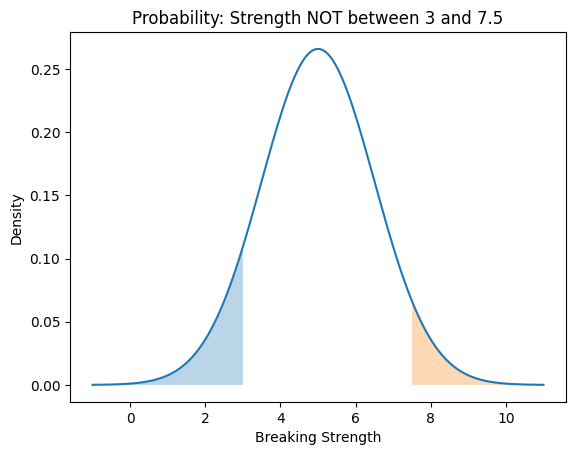

In [18]:
lower = 3
upper = 7.5
prob_between_range = norm.cdf(upper, mean, std_dev) - norm.cdf(lower, mean, std_dev)
prob_not_between = 1 - prob_between_range
print(prob_not_between)

#Visual Representation
x_left = np.linspace(mean - 4*std_dev, lower, 300)
y_left = norm.pdf(x_left, mean, std_dev)

x_right = np.linspace(upper, mean + 4*std_dev, 300)
y_right = norm.pdf(x_right, mean, std_dev)

plt.figure()
plt.plot(x,y)
plt.fill_between(x_left, y_left, alpha = 0.3)
plt.fill_between(x_right, y_right, alpha = 0.3)
plt.title("Probability: Strength NOT between 3 and 7.5")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

###Observation:-

Very few bags fall outside this wide range, showing that extreme weak or very strong cases are rare.

#Problem Statement 3

##Objective:-

The objective of this analysis is to evaluate whether the stones supplied to Zingaro meet the minimum hardness requirement of 150 Brinell hardness units for high quality printing. Specifically, the analysis aims to:


*   Determine whether unpolished stones are suitable for printing based on their average hardness.
*   Examine whether there is a statistically significant difference in mean hardness between polished and unpolished stones.

The findings will help Zingaro make informed decisions on material selection and quality control.



In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Google Drive was mounted to access the dataset stored externally.

In [20]:
df = pd.read_csv('/content/drive/MyDrive/Zingaro_Company.csv')

The dataset was successfully loaded into a DataFrame for further analysis.

##Data Overview

In [21]:
print(df.shape)

(75, 2)


###Observation:
The dataset contains 75 observations and 2 variables, corresponding to hardness values for unpolished and treated-and-polished stones.

In [22]:
print(df.head())

   Unpolished   Treated and Polished
0   164.481713            133.209393
1   154.307045            138.482771
2   129.861048            159.665201
3   159.096184            145.663528
4   135.256748            136.789227


###Observation:-

This shows the first few rows and confirms the column names and values look correct.

In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unpolished            75 non-null     float64
 1   Treated and Polished  75 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB
None


###Observation:-

This confirms that there are no missing values and both columns contain numerical data.

In [24]:
print(df.describe())

       Unpolished   Treated and Polished
count    75.000000             75.000000
mean    134.110527            147.788117
std      33.041804             15.587355
min      48.406838            107.524167
25%     115.329753            138.268300
50%     135.597121            145.721322
75%     158.215098            157.373318
max     200.161313            192.272856


###Observation:-

Both groups have 75 samples each. The average hardness of unpolished stones is around 134, which is below the required threshold of 150, while polished stones have a higher average of about 148, closer to the requirement. Unpolished stones also show much higher variability, indicating inconsistent quality compared to polished stones.

In [25]:
print(df.columns)

#Fixing the error
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Unpolished ', 'Treated and Polished'], dtype='object')
Index(['Unpolished', 'Treated and Polished'], dtype='object')


###Observation:-

Extra spaces in column names have been removed, ensuring the columns can be accessed correctly in the analysis.

##Visualizing the Data

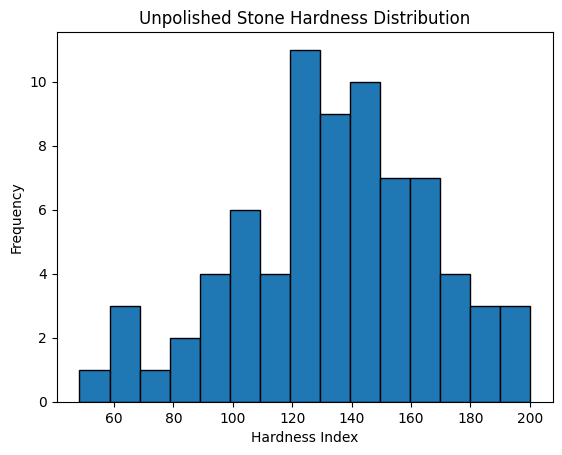

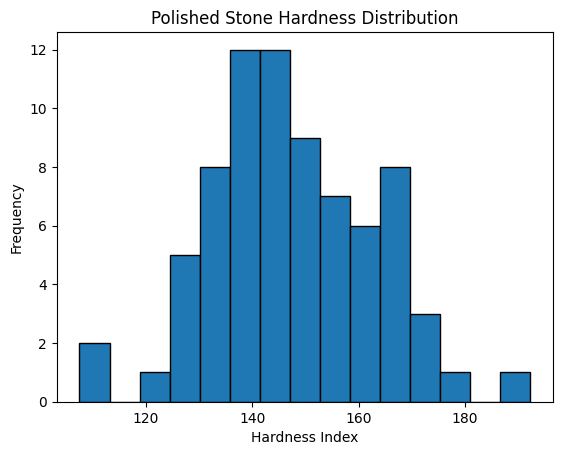

In [26]:
import matplotlib.pyplot as plt

#Histogram for Unpolished stones
plt.figure()
plt.hist(df["Unpolished"], bins=15, edgecolor = "black", linewidth = 1)
plt.title("Unpolished Stone Hardness Distribution")
plt.xlabel("Hardness Index")
plt.ylabel("Frequency")
plt.show()

#Histogram for Polished Stones
plt.figure()
plt.hist(df["Treated and Polished"], bins=15, edgecolor = "black", linewidth = 1)
plt.title("Polished Stone Hardness Distribution")
plt.xlabel("Hardness Index")
plt.ylabel("Frequency")
plt.show()

###Observation:-



*   Most unpolished stones fall between roughly 110 and 160 in hardness, but there are several values well below 150. This shows noticeably variation and explains why some unpolished stones may not meet the printing requirement.
*   Most polished stones are clustered between about 130 and 165 in hardness, with fewer extreme low values. The distribution appears more consistent compared to unpolished stones, indicating better quality control after polishing.



##3.1 Are unpolished stones suitable for printing?

###Hypothesis:-


*   Null Hypothesis (H₀): Means hardness of unpolished stones ≥ 150
*   Alternate Hypothesis (H₁): Means hardness of unpolished stones < 150

(Significance level α = 0.05)


In [27]:
from scipy import stats
unpolished = df["Unpolished"]
t_stat_31, p_value_31 = stats.ttest_1samp(unpolished, popmean = 150)
print(t_stat_31, p_value_31)

-4.164629601426757 8.342573994839304e-05


###Observation:-

Since the p-value is less than 0.05, the null hypothesis is rejected.
This indicates that unpolished stones do not meet the minimum hardness requirement and may not be suitable for printing. Zingaro is justified in this concern.

##3.2 Is the mean hardness of polished and unpolished stones the same?

###Hypotheses



*   Null Hypothesis (H₀): Mean hardness of polished stones = Mean hardness of unpolished stones
*   Alternate Hypothesis (H₁): Mean hardness of polished stones ≠ Mean hardness of unpolished stones

(Significance level α = 0.05)



In [28]:
polished = df["Treated and Polished"]
t_stat_32, p_value_32 = stats.ttest_ind(polished, unpolished, equal_var = False)
print(t_stat_32, p_value_32)

3.242232050141406 0.001588379295584306


###Observation:-

Since the p-value is less than 0.05, the null hypothesis is rejected.
This confirms that polishing has a significant impact on stone hardness, with polished stones showing higher average hardness.

##Overall Summary:-
Unpolished stones generally fall below the required hardness level and are not reliable for printing. Polishing significantly improves hardness and consistency, making polished stones the better choice for maintaining print quality.

#Problem Statement 4

##Objective:-
The objective is to understand how the hardness of dental implants varies based on:


*   The dentist performing the implant,
*   The method used, and


*   The interaction between dentist and method,

for each alloy separately.

This helps identify which combinations deliver better hardness consistency.





In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Drive was mounted to access the dataset stored externally.

In [30]:
df = pd.read_excel('/content/drive/MyDrive/Dental Hardness data.xlsx')

The dataset was successfully loaded into a DataFrame for further analysis.

##Data Overview

In [31]:
print(df.shape)

(90, 5)


In [32]:
print(df.head())

   Dentist  Method  Alloy  Temp  Response
0        1       1      1  1500       813
1        1       1      1  1600       792
2        1       1      1  1700       792
3        1       1      2  1500       907
4        1       1      2  1600       792


###Observation:-
Each record shows the dentist, method, alloy, temperature, and the corresponding hardness value for a dental implant sample.

In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Dentist   90 non-null     int64
 1   Method    90 non-null     int64
 2   Alloy     90 non-null     int64
 3   Temp      90 non-null     int64
 4   Response  90 non-null     int64
dtypes: int64(5)
memory usage: 3.6 KB
None


###Observation:-
The dataset contains 90 records with no missing values. All variables are numeric, indicating the data is clean and ready for statistical analysis without additional preprocessing.

In [34]:
print(df.describe())

         Dentist     Method      Alloy         Temp     Response
count  90.000000  90.000000  90.000000    90.000000    90.000000
mean    3.000000   2.000000   1.500000  1600.000000   741.777778
std     1.422136   0.821071   0.502801    82.107083   145.767845
min     1.000000   1.000000   1.000000  1500.000000   289.000000
25%     2.000000   1.000000   1.000000  1500.000000   698.000000
50%     3.000000   2.000000   1.500000  1600.000000   767.000000
75%     4.000000   3.000000   2.000000  1700.000000   824.000000
max     5.000000   3.000000   2.000000  1700.000000  1115.000000


###Observation:-
The response values range widely, indicating noticeable variability in implant hardness. Dentists and methods are represented across multiple levels, and temperature values vary between 1500 and 1700, suggesting the dataset captures diverse operating conditions.

In [35]:
print(df.columns)

Index(['Dentist', 'Method', 'Alloy', 'Temp', 'Response'], dtype='object')


###Observation:-
All column names are correct and readable, so there should not be any issues while doing the anlysis.

##Segregation of Alloys

In [36]:
#Separating data by Alloy

print(df["Alloy"].value_counts())

alloy1 = df[df["Alloy"] == 1]
alloy2 = df[df["Alloy"] == 2]

Alloy
1    45
2    45
Name: count, dtype: int64


###Observation:-
Both alloy types have an equal number of samples (45 each), so the data is balanced for separate analysis.

#Alloy 1 Analysis

##4.1 Hardness variation based on Dentist

###Hypotheses
H₀: All dentists have the same average hardness

H₁: Atleast one dentist has a different average hardness.

###Checking Assumption 1 - Normality

In [37]:
from scipy.stats import shapiro
for dentist, group in alloy1.groupby("Dentist"):
  stat, p = shapiro(group["Response"])
  print("Dentist", dentist, "p-value:", p)

Dentist 1 p-value: 0.3254693632188942
Dentist 2 p-value: 0.841544387628862
Dentist 3 p-value: 0.12953560483047716
Dentist 4 p-value: 0.05333654291277101
Dentist 5 p-value: 0.08127790851660108


###Observation:-
Most of the dentist groups have p-values above 0.05, so the data looks fairly normal overall. A couple of values are close to the cutoff, but nothing looks concerning.

###Checking Assumption 2 - Equal Variance

In [38]:
from scipy.stats import levene
groups = [group["Response"] for name, group in alloy1.groupby("Dentist")]
levene(*groups)

LeveneResult(statistic=np.float64(1.3847146992797106), pvalue=np.float64(0.2565537418543795))

###Observation:-
The p-value is greater than 0.05, which suggests the variances across dentists are fairly similar.

##One way ANOVA Test

In [39]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f_stat, p_value)

1.977111990877085 0.11656712140267628


The p-value is greater than 0.05, which means there is no strong evidence that hardness differs across dentists for this alloy.

###Post-Hoc Test

In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_dentist = pairwise_tukeyhsd(
    endog = alloy1["Response"],
    groups = alloy1["Dentist"],
    alpha = 0.05
)
print(tukey_dentist)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   11.3333 0.9996 -145.0423  167.709  False
     1      3  -32.3333 0.9757  -188.709 124.0423  False
     1      4  -68.7778 0.7189 -225.1535  87.5979  False
     1      5 -122.2222 0.1889 -278.5979  34.1535  False
     2      3  -43.6667 0.9298 -200.0423  112.709  False
     2      4  -80.1111 0.5916 -236.4868  76.2646  False
     2      5 -133.5556 0.1258 -289.9312  22.8201  False
     3      4  -36.4444 0.9626 -192.8201 119.9312  False
     3      5  -89.8889 0.4805 -246.2646  66.4868  False
     4      5  -53.4444 0.8643 -209.8201 102.9312  False
--------------------------------------------------------


###Observation:-
All the comparisons show "False" in the reject column, meaning none of the dentist pairs differ significantly in hardness.

##4.2 Hardness variation based on Method

###Hypotheses:-


*   H₀: All methods have the same average hardness
*   H₁: At least one method differs



In [41]:
groups_method = [group["Response"] for name, group in alloy1.groupby("Method")]
f_stat_m, p_value_m = f_oneway(*groups_method)
print(f_stat_m, p_value_m)

6.263326635486233 0.0041634121675055424


###Observation:-
The p-value is below 0.05, which means the hardness differs across methods for this alloy.

##4.3 Interaction between Dentist and Method

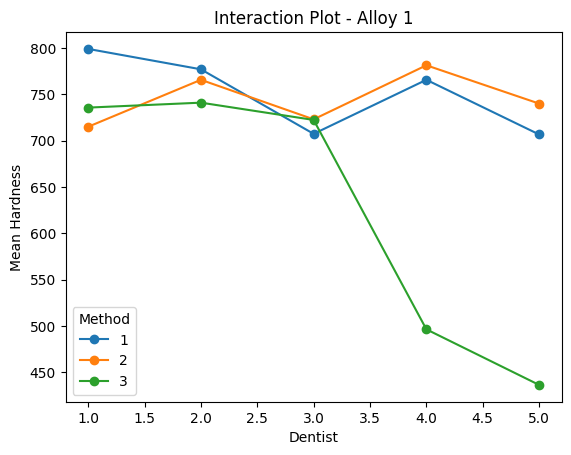

In [42]:
import matplotlib.pyplot as plt
interaction_means = alloy1.groupby(["Dentist", "Method"])["Response"].mean().unstack()

interaction_means.plot(marker = 'o')
plt.title("Interaction Plot - Alloy 1")
plt.ylabel("Mean Hardness")
plt.show()

###Observation:-
The lines are not parallel and cross at a few points, especially for Method 3, which drops sharply for some dentists. This suggests that the effect of the method changes depending on the dentist.

##4.4 Two-Way ANOVA

In [43]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)', data=alloy1).fit()
anova_table = sm.stats.anova_lm(model, typ = 2)
print(anova_table)

                             sum_sq    df          F    PR(>F)
C(Dentist)            106683.688889   4.0   3.899638  0.011484
C(Method)             148472.177778   2.0  10.854287  0.000284
C(Dentist):C(Method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN


###Observation:-
The p-values for dentist, method, and their interaction are all below 0.05, which means each of these factors has a significant effect on hardness. This shows that not only d dentists and methods matter individually, but their combination also influences the result.

#Alloy 2 Analysis

##4.1 Hardness variation based on Dentist

###Hypotheses
H₀: All dentists have the same average hardness

H₁: Atleast one dentist has a different average hardness.

###Checking Assumption 1 - Normality

In [44]:
from scipy.stats import shapiro
for dentist, group in alloy2.groupby("Dentist"):
  stat, p = shapiro(group["Response"])
  print("Dentist", dentist, "p-value:", p)

Dentist 1 p-value: 0.27593872565209243
Dentist 2 p-value: 0.5735055333426523
Dentist 3 p-value: 0.5213087304159562
Dentist 4 p-value: 0.007332685121063265
Dentist 5 p-value: 0.33861078485472895


###Observation:-
Most dentist groups have p-values above 0.05, although one group shows a lower value. Overall, the data looks reasonably close to normal.

###Checking Assumption 2 - Equal Variance

In [45]:
from scipy.stats import levene
groups = [group["Response"] for name, group in alloy2.groupby("Dentist")]
levene(*groups)

LeveneResult(statistic=np.float64(1.4456166464566966), pvalue=np.float64(0.23686777576324952))

###Observation:-
The p-value is above 0.05, which suggests the variability across dentists is fairly similar for this alloy.

##One way ANOVA Test

In [46]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(*groups)
print(f_stat, p_value)

0.5248351000282961 0.7180309510793431


The p-value is much higher than 0.05, which means there is no clear difference in hardness across the groups in this case.

###Post-Hoc test

In [47]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_dentist = pairwise_tukeyhsd(
    endog = alloy2["Response"],
    groups = alloy2["Dentist"],
    alpha = 0.05
)
print(tukey_dentist)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2  -4.1111    1.0 -225.5687 217.3465  False
     1      3 -36.5556 0.9895 -258.0131  184.902  False
     1      4    -70.0 0.8941 -291.4576 151.4576  False
     1      5 -90.1111 0.7724 -311.5687 131.3465  False
     2      3 -32.4444 0.9933  -253.902 189.0131  False
     2      4 -65.8889 0.9132 -287.3465 155.5687  False
     2      5    -86.0 0.8008 -307.4576 135.4576  False
     3      4 -33.4444 0.9925  -254.902 188.0131  False
     3      5 -53.5556 0.9574 -275.0131  167.902  False
     4      5 -20.1111  0.999 -241.5687 201.3465  False
-------------------------------------------------------


###Observation:-
All the dentist pair comparisons show "False" under reject, meaning none of the dentists differ significantly in hardness for this alloy.

##4.2 Hardness variation based on method

###Hypotheses:-


*   H₀: All methods have the same average hardness
*   H₁: At least one method differs


In [48]:
groups_method = [group["Response"] for name, group in alloy2.groupby("Method")]
f_stat_m, p_value_m = f_oneway(*groups_method)
print(f_stat_m, p_value_m)

16.410799884384815 5.4158710514431865e-06


###Observation:-
The p-value is extremely small, which shows that hardness varies significantly across methods for this alloy.

##4.3 Interaction between Dentist and Method

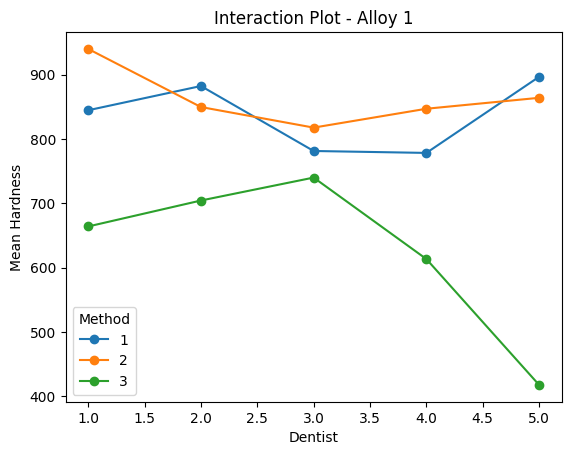

In [49]:
import matplotlib.pyplot as plt
interaction_means = alloy2.groupby(["Dentist", "Method"])["Response"].mean().unstack()

interaction_means.plot(marker = 'o')
plt.title("Interaction Plot - Alloy 1")
plt.ylabel("Mean Hardness")
plt.show()

###Observation:-
The gaps between methods change as the dentist changes, and the lines intersect at multiple points. This suggets that dentist and method influence each other's effect on hardness.

##4.4 Two-way ANOVA

In [50]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)', data=alloy2).fit()
anova_table = sm.stats.anova_lm(model, typ = 2)
print(anova_table)

                             sum_sq    df          F    PR(>F)
C(Dentist)             56797.911111   4.0   1.106152  0.371833
C(Method)             499640.400000   2.0  19.461218  0.000004
C(Dentist):C(Method)  197459.822222   8.0   1.922787  0.093234
Residual              385104.666667  30.0        NaN       NaN


###Observation:-
The method has a strong effect on hardness since its p-value is well below 0.05. The dentist and the interaction between dentist and method do not appear to be significant for this alloy.

##Overall Summary
The anslysis shows that the hardness of dental implants is influenced by dentists, methods, and their interaction, but the impact differs across the two alloys.


*   **For Alloy 1:** the method used has a clear effect on hardness, and the interaction plot shows that the performance of a method changes depending on the dentist. The two way ANOVA also confirms that dentist, method, and their interaction are statistically significant. This suggests that both technique and operator matter for this alloy, and certain dentist-method combinations perform better than others.

*   **For Alloy 2:** the method again plays a strong role in determining hardness, but the dentist and the interaction effect are not statistically significant. This indicates that Alloy 2 behaves more consistently across dentists, and the choice of method is the main factor affecting hardness.

Overall, the results suggest that process standardization is especially important for Alloy 1, where outcomes depend on both who performs the procedure and how it is done. For Alloy 2, focusing on selecting the right method is likely sufficient to maintain consistent hardness levels.

